In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importando os dados

Este conjunto de dados contém informações sobre os membros do Vingadores da Marvel. Cada entrada no conjunto de dados inclui detalhes como o nome ou alias do personagem, número de apariações, gênero, data de entrada na equipe dos Vingadores, status atual, e informações sobre possíveis mortes e retornos.

Fonte: https://github.com/fivethirtyeight/data/tree/master/avengers

In [99]:
df = pd.read_csv('../data/avengers.csv', encoding='ISO-8859-1')
df.head()

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,NaN,Sep-63,1963,52,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Merged with Ultron in Rage of Ultron Vol. 1. A...
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Secret Invasion V1:I8. Actually was se...
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Death: ""Later while under the influence of Imm..."
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dies in Ghosts of the Future arc. However ""he ..."
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Fear Itself brought back because that'...


## 2. Análise Exploratória de Dados

In [100]:
df.dtypes

URL                              str
Name/Alias                       str
Appearances                    int64
Current?                         str
Gender                           str
Probationary Introl              str
Full/Reserve Avengers Intro      str
Year                           int64
Years since joining            int64
Honorary                         str
Death1                           str
Return1                          str
Death2                           str
Return2                          str
Death3                           str
Return3                          str
Death4                           str
Return4                          str
Death5                           str
Return5                          str
Notes                            str
dtype: object

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   URL                          173 non-null    str  
 1   Name/Alias                   163 non-null    str  
 2   Appearances                  173 non-null    int64
 3   Current?                     173 non-null    str  
 4   Gender                       173 non-null    str  
 5   Probationary Introl          15 non-null     str  
 6   Full/Reserve Avengers Intro  159 non-null    str  
 7   Year                         173 non-null    int64
 8   Years since joining          173 non-null    int64
 9   Honorary                     173 non-null    str  
 10  Death1                       173 non-null    str  
 11  Return1                      69 non-null     str  
 12  Death2                       17 non-null     str  
 13  Return2                      16 non-null     str  
 14  Death

Prenchendo os valores faltantes da coluna 'Return1' com 'NO'

In [102]:
df.fillna({'Return1': 'NO'}, inplace=True)

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,NaN,Sep-63,1963,52,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Merged with Ultron in Rage of Ultron Vol. 1. A...
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Secret Invasion V1:I8. Actually was se...
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Death: ""Later while under the influence of Imm..."
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dies in Ghosts of the Future arc. However ""he ..."
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Fear Itself brought back because that'...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,http://marvel.wikia.com/Eric_Brooks_(Earth-616)#,Eric Brooks,198,YES,MALE,NaN,13-Nov,2013,2,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,http://marvel.wikia.com/Adam_Brashear_(Earth-6...,Adam Brashear,29,YES,MALE,NaN,14-Jan,2014,1,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,http://marvel.wikia.com/Victor_Alvarez_(Earth-...,Victor Alvarez,45,YES,MALE,NaN,14-Jan,2014,1,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,http://marvel.wikia.com/Ava_Ayala_(Earth-616)#,Ava Ayala,49,YES,FEMALE,NaN,14-Jan,2014,1,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Convertendo os valores das colunas 'Death1' e 'Return1' para valores numéricos, sendo 1, quando o texto for 'YES', e 0, quando o texto for 'NO'.

In [103]:
df['Death1'] = df['Death1'].replace({'YES': 1, 'NO': 0})

In [104]:
df['Return1'] = df['Return1'].replace({'YES': 1, 'NO': 0})

Cálculo da porcentagem de valores nulos por coluna

In [105]:
total_nulos = df.isnull().sum()
total_linhas = len(df)
porcentagem = (total_nulos / total_linhas) * 100
porcentagem

URL                             0.000000
Name/Alias                      5.780347
Appearances                     0.000000
Current?                        0.000000
Gender                          0.000000
Probationary Introl            91.329480
Full/Reserve Avengers Intro     8.092486
Year                            0.000000
Years since joining             0.000000
Honorary                        0.000000
Death1                          0.000000
Return1                         0.000000
Death2                         90.173410
Return2                        90.751445
Death3                         98.843931
Return3                        98.843931
Death4                         99.421965
Return4                        99.421965
Death5                         99.421965
Return5                        99.421965
Notes                          56.647399
dtype: float64

Removendo as colunas com valores nulos maiores que 10% da coluna

In [106]:
df = df.drop(['Probationary Introl','Death2', 'Return2', 'Death3',
              'Return3', 'Death4', 'Return4', 'Death5', 'Return5',
              'Notes'], axis=1)

In [107]:
df.head()

,URL,Name/Alias,Appearances,Current?,Gender,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,Death1,Return1
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,Sep-63,1963,52,Full,1,0
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,Sep-63,1963,52,Full,1,1
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,Sep-63,1963,52,Full,1,1
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,Sep-63,1963,52,Full,1,1
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,Sep-63,1963,52,Full,1,1


In [108]:
df.describe()

,Appearances,Year,Years since joining
count,173.000000,173.000000,173.000000
mean,414.052023,1988.445087,26.554913
std,677.991950,30.374669,30.374669
min,2.000000,1900.000000,0.000000
25%,58.000000,1979.000000,5.000000
50%,132.000000,1996.000000,19.000000
75%,491.000000,2010.000000,36.000000
max,4333.000000,2015.000000,115.000000


## 3. Qual a distribuição de gêneros dos personagens?

Qual é a quantidade de heróis no nosso conjunto de dados?

In [109]:
total_herois = df['Name/Alias'].count()
total_herois

np.int64(163)

Temos no total 163 heróis e agora vamos descobrir como é a divisão por gênero

In [110]:
quant_genero = df['Gender'].value_counts()
quant_genero

Gender
MALE      115
FEMALE     58
Name: count, dtype: int64

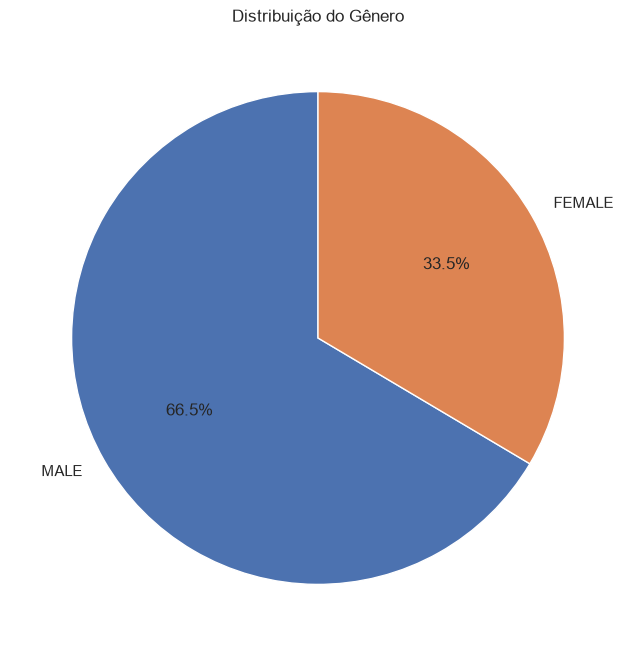

In [111]:
# Tema do Seaborn
sns.set_theme(style='darkgrid')

# Gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(
    quant_genero.values,
    labels=quant_genero.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribuição do Gênero')
plt.show()

Neste gráfico de pizza mostra que a maioria dos heróis possuem o gênero Male (Masculino)

## 4. Qual é a média de aparições dos personagens?

Vamos utilizar um histograma para verificar a distribuição dessa coluna.

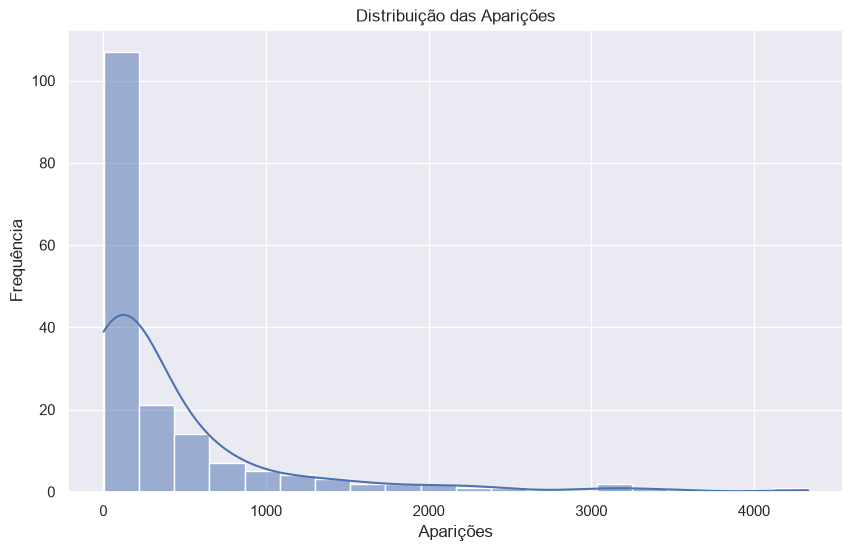

In [112]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Appearances',
    bins=20,
    kde=True
)

plt.title('Distribuição das Aparições')
plt.xlabel('Aparições')
plt.ylabel('Frequência')
plt.show()

Observamos neste histograma que a  maioria dos heróis tem no máximo 500 aparições.

## 5. Vamos verificar se a distribuição de aparições é muito diferente para cada um dos gêneros

C:\Users\hccru\AppData\Local\Temp\ipykernel_21732\810963470.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Masculino', 'Feminino'])


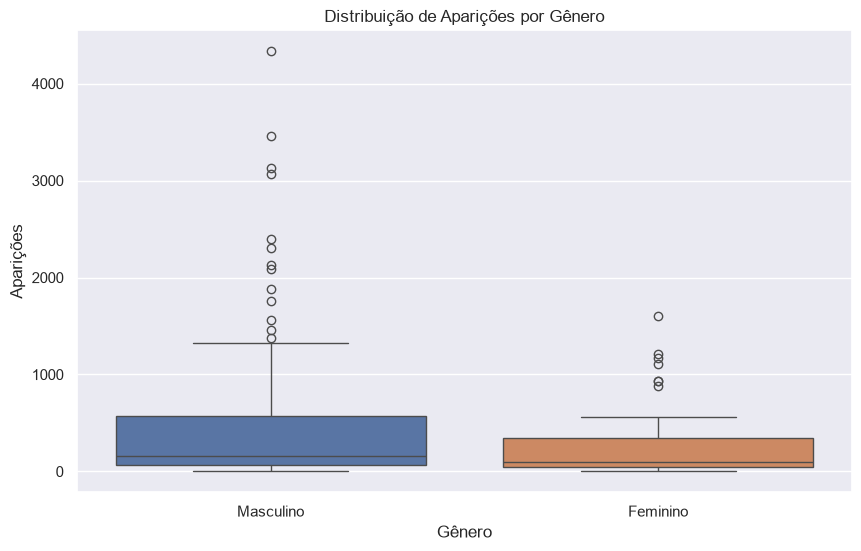

In [113]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data = df,
    x='Gender',
    y='Appearances',
    hue='Gender'
)

ax.set_xticklabels(['Masculino', 'Feminino'])

plt.title('Distribuição de Aparições por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Aparições')
plt.show()

Com este gráfico, podemos observar como gênero e aparições se relacionam. Demonstrando que os heróis do gênero masculino costumam ter mais aparições.

## 6. Como a adesão dos heróis ao grupo dos Avengers ao longo dos anos se modificou?

In [114]:
quant_herois_ano = df['Year'].value_counts()
quant_herois_ano

Year
2013    24
2005    16
2010    16
1900    14
1989    11
1978     8
1963     6
1988     5
1992     5
1965     4
1993     4
2007     4
2012     4
1976     3
1979     3
1984     3
1987     3
1990     3
2011     3
2014     3
1968     2
1973     2
2009     2
1996     2
1998     2
2000     2
2006     2
2008     2
2015     2
1964     1
1967     1
1969     1
1975     1
1981     1
1982     1
1983     1
1986     1
1991     1
1985     1
2003     1
2001     1
2004     1
Name: count, dtype: int64

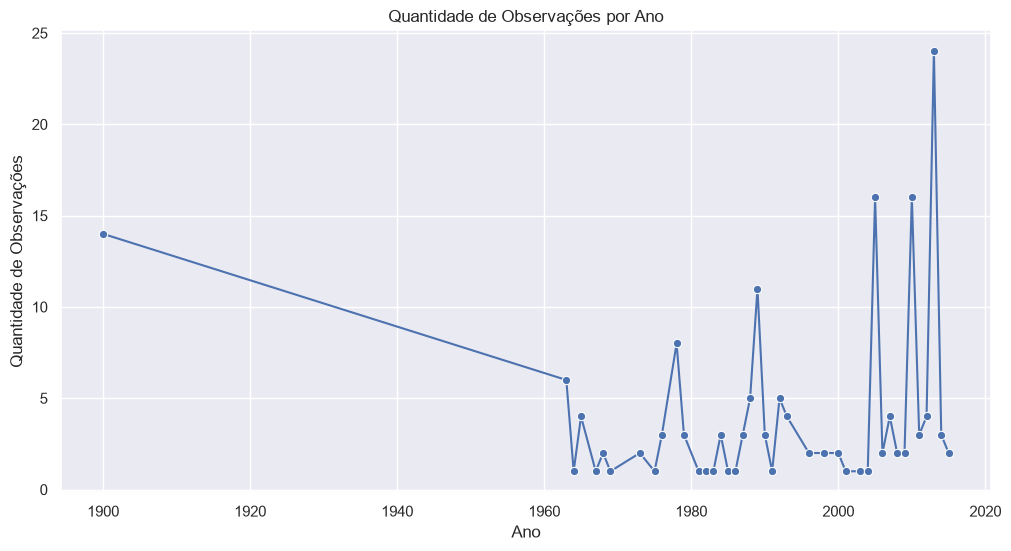

In [115]:
plt.figure(figsize=(12,6))

sns.lineplot(quant_herois_ano, marker='o')

plt.title('Quantidade de Observações por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Observações')
plt.show()

Sabendo que a Marvel foi criada somente em 1939, o gráfico tem um padrão bem estrano no início da série. Agora, vamos refazer este gráfico, porém retirando os super-heróis antes 1939 que provalvelmente foram informados na coluna 'Year' incorretamente.

In [116]:
df_maior_1939 = df[df['Year'] > 1939]
quant_herois_ano_Marvel = df_maior_1939['Year'].value_counts()
quant_herois_ano_Marvel

Year
2013    24
2005    16
2010    16
1989    11
1978     8
1963     6
1988     5
1992     5
1965     4
1993     4
2007     4
2012     4
1976     3
1979     3
1984     3
1987     3
1990     3
2011     3
2014     3
1968     2
1973     2
2009     2
1996     2
1998     2
2000     2
2006     2
2008     2
2015     2
1964     1
1967     1
1969     1
1975     1
1981     1
1982     1
1983     1
1986     1
1991     1
1985     1
2003     1
2001     1
2004     1
Name: count, dtype: int64

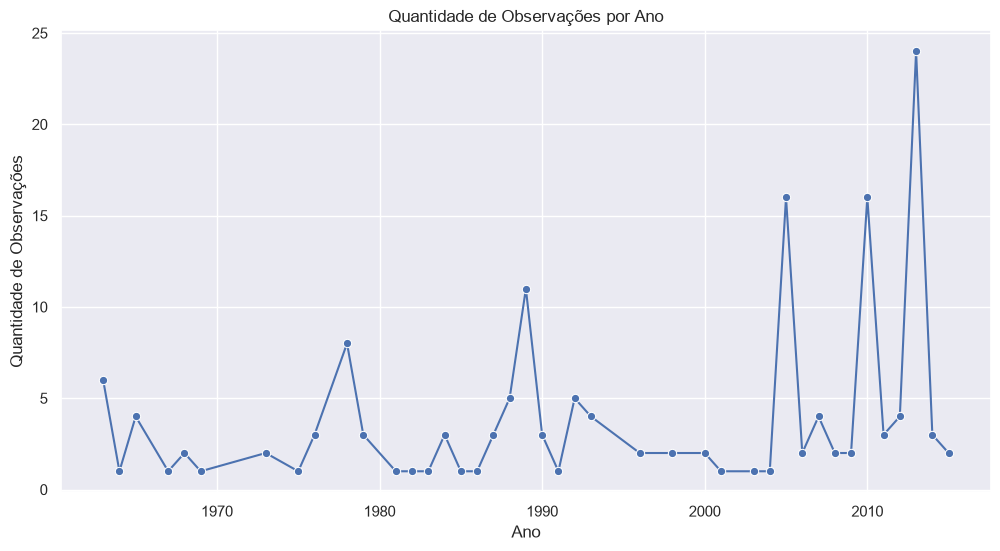

In [117]:
plt.figure(figsize=(12,6))

sns.lineplot(quant_herois_ano_Marvel, marker='o')

plt.title('Quantidade de Observações por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Observações')
plt.show()

## 7. Como foi a distribuição de Gênero ao longo dos anos?

In [118]:
df['Decada'] = (df['Year'] // 10) * 10
df.head()

,URL,Name/Alias,Appearances,Current?,Gender,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,Death1,Return1,Decada
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,Sep-63,1963,52,Full,1,0,1960
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,Sep-63,1963,52,Full,1,1,1960
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,Sep-63,1963,52,Full,1,1,1960
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,Sep-63,1963,52,Full,1,1,1960
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,Sep-63,1963,52,Full,1,1,1960


In [119]:
contagem = (
    df.groupby(['Decada', 'Gender'])
    .size()
    .reset_index(name='Numero de Personagens')
)

contagem

,Decada,Gender,Numero de Personagens
0,1900,FEMALE,7
1,1900,MALE,7
2,1960,FEMALE,2
3,1960,MALE,13
4,1970,FEMALE,6
5,1970,MALE,11
6,1980,FEMALE,11
7,1980,MALE,16
8,1990,FEMALE,8
9,1990,MALE,9


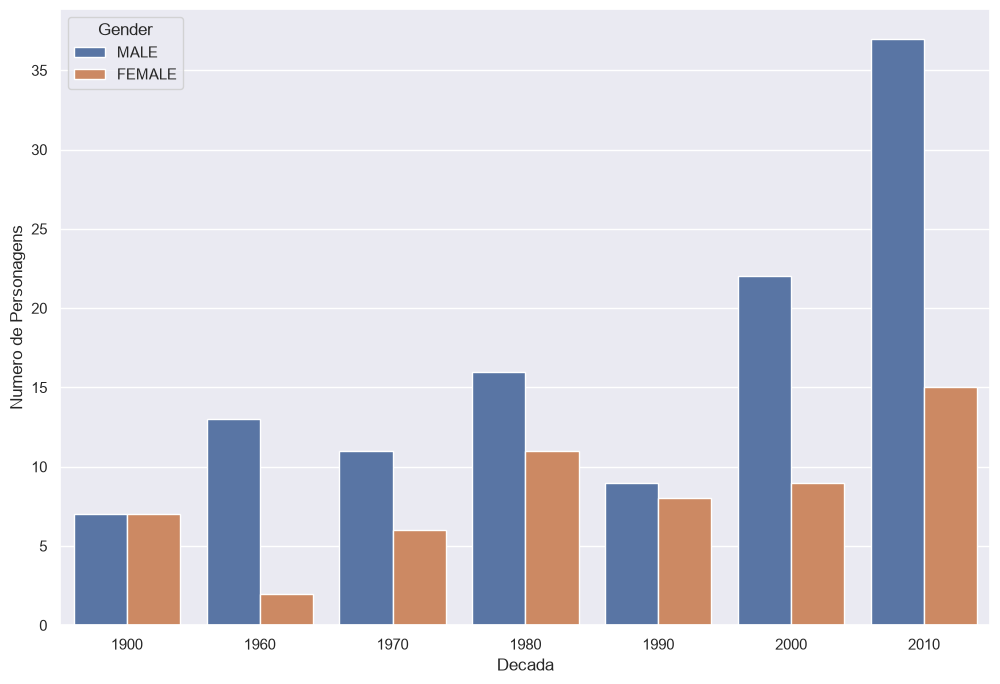

In [120]:
plt.figure(figsize=(12,8))

sns.barplot(data=contagem, x='Decada', y='Numero de Personagens', hue='Gender', hue_order=['MALE', 'FEMALE'])

plt.show()

Observamos que o número de personagens que participam dos Vingadores vinha crescendo ao longo dos anos, mas teve uma queda ma década de 1990. O motivo da queda pode ser uma diminuição nas vendas de quadrinhos ou uma escolha da Marvel em não lançar quadrinhos sobre os Vingadores. Na década seguinte, o crescimento dos personagens de gênero masculino foi muito maior que do gênero feminino.

## 8. Existe alguma diferença na proporção de  personagens honorários para cada um dos gêneros?

In [121]:
honorario_genero = (
    df.groupby(['Gender','Honorary']).size().unstack(fill_value=0)
)
honorario_genero

Honorary,Academy,Full,Honorary,Probationary
Gender,,,,
FEMALE,9,43,6,0
MALE,8,95,10,2


In [122]:
honorario_genero_freq = honorario_genero.div(honorario_genero.sum(axis=0), axis=1) * 100
honorario_genero_freq.style.format('{:.2f}%')

Honorary,Academy,Full,Honorary,Probationary
Gender,,,,
FEMALE,52.94%,31.16%,37.50%,0.00%
MALE,47.06%,68.84%,62.50%,100.00%


In [123]:
genero_honorario_freq = honorario_genero.div(honorario_genero.sum(axis=1), axis=0) * 100
genero_honorario_freq.style.format('{:.2f}%')

Honorary,Academy,Full,Honorary,Probationary
Gender,,,,
FEMALE,15.52%,74.14%,10.34%,0.00%
MALE,6.96%,82.61%,8.70%,1.74%


## 9. Verificar a diferença no número de mortes dos personagens para cada gênero, em termos absolutos e relativos. Dentre as mortes verificadas, verificar qual o percentual de personagens que retornaram de cada gênero.

In [124]:
mortes_genero_abs = (
    df.groupby(['Gender','Death1']).size().unstack(fill_value=0)
)
mortes_genero_abs

Death1,0,1
Gender,,
FEMALE,37,21
MALE,67,48


Nos dois gêneros, a quantidade de registros sem ocorrência do evento de óbito (Death1 = 0) é superior à quantidade de registros com ocorrência de óbito (Death1 = 1). Entre as mulheres, foram observados 37 casos sem óbito e 21 com óbito, enquanto entre os homens foram registrados 67 casos sem óbito e 48 com óbito.

In [125]:
mortes_genero_rel = mortes_genero_abs.div(mortes_genero_abs.sum(axis=0), axis=1) * 100
mortes_genero_rel.style.format('{:.2f}%')

Death1,0,1
Gender,,
FEMALE,35.58%,30.43%
MALE,64.42%,69.57%


Observa-se que o gênero MALE é predominante tanto entre os sobreviventes quanto entre os indivíduos que foram a óbito. Além disso, a proporção de MALE é ligeiramente maior no grupo de óbitos (69,57%) do que no grupo de não óbitos (64,42%), enquanto o gênero FEMALE diminui de 35,58% para 30,43%.

In [126]:
genero_mortes_rel = mortes_genero_abs.div(mortes_genero_abs.sum(axis=1), axis=0) * 100
genero_mortes_rel.style.format('{:.2f}%')

Death1,0,1
Gender,,
FEMALE,63.79%,36.21%
MALE,58.26%,41.74%


O gênero FEMALE do conjunto de dados apresenta uma proporção de óbitos de aproximadamente 36,21%, enquanto entre o gênero MALE essa proporção foi de 41,74%. Isso sugere que, proporcionalmente, a ocorrência de óbito foi mais frequente no grupo MALE. Da mesma forma, a proporção de sobreviventes foi maior entre FEMALE (63,79%) do que entre MALE (58,26%).

Os resultados indicam uma possível associação entre gênero e ocorrência de óbito, com o gênero MALE apresentando uma taxa de mortalidade relativamente maior na amostra analisada. Entretanto, essa diferença observada pode ser decorrente de variações amostrais.

In [127]:
df_mortes = df[df['Death1'] == 1]
df_mortes.head(10)

,URL,Name/Alias,Appearances,Current?,Gender,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,Death1,Return1,Decada
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,Sep-63,1963,52,Full,1,0,1960
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,Sep-63,1963,52,Full,1,1,1960
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,Sep-63,1963,52,Full,1,1,1960
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,Sep-63,1963,52,Full,1,1,1960
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,Sep-63,1963,52,Full,1,1,1960
6,http://marvel.wikia.com/Steven_Rogers_(Earth-616),Steven Rogers,3458,YES,MALE,Mar-64,1964,51,Full,1,1,1960
7,http://marvel.wikia.com/Clint_Barton_(Earth-616),Clinton Francis Barton,1456,YES,MALE,May-65,1965,50,Full,1,1,1960
8,http://marvel.wikia.com/Pietro_Maximoff_(Earth...,Pietro Maximoff,769,YES,MALE,May-65,1965,50,Full,1,1,1960
9,http://marvel.wikia.com/Wanda_Maximoff_(Earth-...,Wanda Maximoff,1214,YES,FEMALE,May-65,1965,50,Full,1,1,1960
10,http://marvel.wikia.com/Jacques_Duquesne_(Eart...,Jacques Duquesne,115,NO,MALE,Sep-65,1965,50,Full,1,1,1960


In [128]:
retornos_genero_abs = (
    df_mortes.groupby(['Gender', 'Return1']).size().unstack(fill_value=0)
)
retornos_genero_abs

Return1,0,1
Gender,,
FEMALE,5,16
MALE,18,30


Observa-se que o gênero MALE apresenta maior quantidade de registros em ambas as categorias de retorno. Entre o gênero FEMALE, 16 registros apresentaram retorno igual a 1 e 5 registros retorno igual a 0, indicando uma proporção maior de retornos positivos dentro desse grupo. Entre o MALE, 30 registros apresentaram retorno igual a 1 e 18 registros retorno igual a 0. Embora o número absoluto de retornos positivos seja maior entre o MALE, essa diferença pode estar relacionada ao maior número de observações MALE na amostra. Para uma comparação mais adequada entre os gêneros, recomenda-se analisar as frequências relativas (percentuais) em vez das frequências absolutas.

In [129]:
retornos_genero_rel = retornos_genero_abs.div(retornos_genero_abs.sum(axis=0), axis=1) * 100
retornos_genero_rel.style.format('{:.2f}%')

Return1,0,1
Gender,,
FEMALE,21.74%,34.78%
MALE,78.26%,65.22%


Observa-se que o gênero MALE representa a maioria dos registros em ambas as categorias de retorno. No entanto, o gênero FEMALE é maior no grupo com Return1 = 1 (34,78%) do que no grupo com Return1 = 0 (21,74%). Em contrapartida, o gênero MALE diminui de 78,26% para 65,22% quando se passa da categoria 0 para a categoria 1.

In [130]:
genero_retornos_rel = retornos_genero_abs.div(retornos_genero_abs.sum(axis=1), axis=0) * 100
genero_retornos_rel.style.format('{:.2f}%')

Return1,0,1
Gender,,
FEMALE,23.81%,76.19%
MALE,37.50%,62.50%


O gênero FEMALE apresenta uma maior proporção de retornos iguais a 1 (76,19%) em comparação ao gênero MALE (62,50%). Isso sugere que, proporcionalmente, o grupo FEMALE obteve melhor desempenho no indicador analisado.

## 10. Criar uma coluna quartil ao qual o número de aparições de cad persoangem pertenc. Verificar o percentual de mortes para cada quartil.

In [131]:
df['Quartil'] = pd.qcut(df['Appearances'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df.head()

,URL,Name/Alias,Appearances,Current?,Gender,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,Death1,Return1,Decada,Quartil
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,Sep-63,1963,52,Full,1,0,1960,Q4
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,Sep-63,1963,52,Full,1,1,1960,Q4
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,Sep-63,1963,52,Full,1,1,1960,Q4
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,Sep-63,1963,52,Full,1,1,1960,Q4
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,Sep-63,1963,52,Full,1,1,1960,Q4


In [132]:
mortes_quartil = (
    df.groupby(['Quartil','Death1']).size().unstack(fill_value=0)
)
mortes_quartil

Death1,0,1
Quartil,,
Q1,30,14
Q2,30,14
Q3,22,20
Q4,22,21


In [133]:
mortes_quartil_perc = mortes_quartil.div(mortes_quartil.sum(axis=0), axis=1) * 100
mortes_quartil_perc.style.format('{:.2f}%')

Death1,0,1
Quartil,,
Q1,28.85%,20.29%
Q2,28.85%,20.29%
Q3,21.15%,28.99%
Q4,21.15%,30.43%


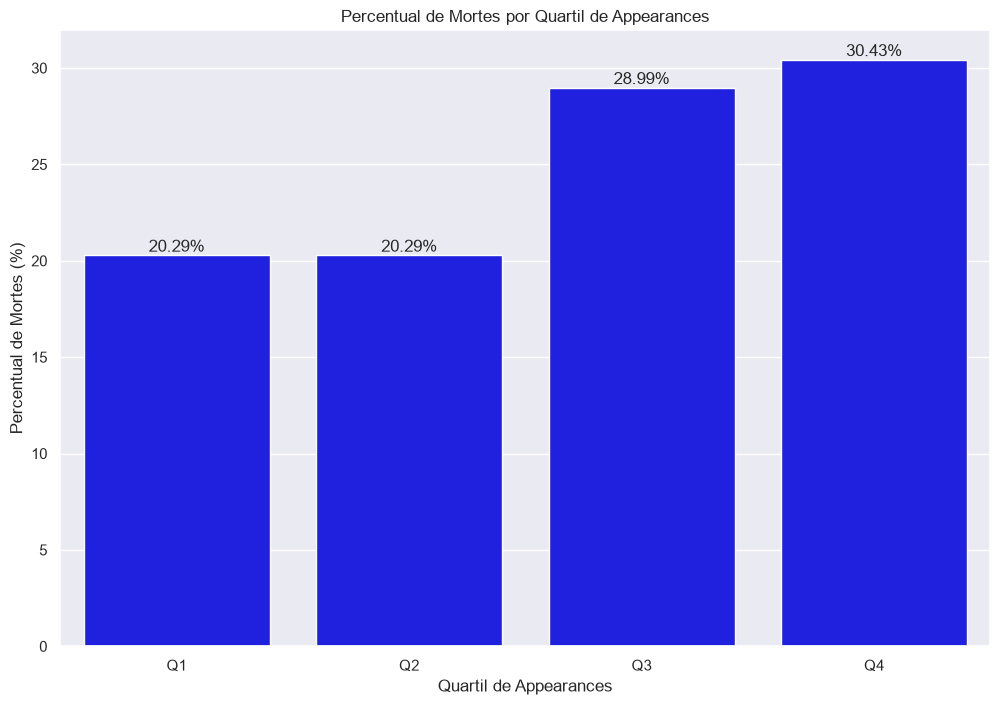

In [134]:
plt.figure(figsize=(12,8))

ax = sns.barplot(data=mortes_quartil_perc, x='Quartil', y=1, color='blue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title('Percentual de Mortes por Quartil de Appearances')
plt.xlabel('Quartil de Appearances')
plt.ylabel('Percentual de Mortes (%)')
plt.show()

Os resultados indicam que os quartis superiores de Appearances apresentam percentuais de mortalidade mais elevados do que os quartis inferiores. Essa tendência sugere uma possível relação entre o número de aparições e a ocorrência de morte.

## 11. Verificar se a média de aparições dos personagens varia de acordo com o gênero e a ocorrência de morte

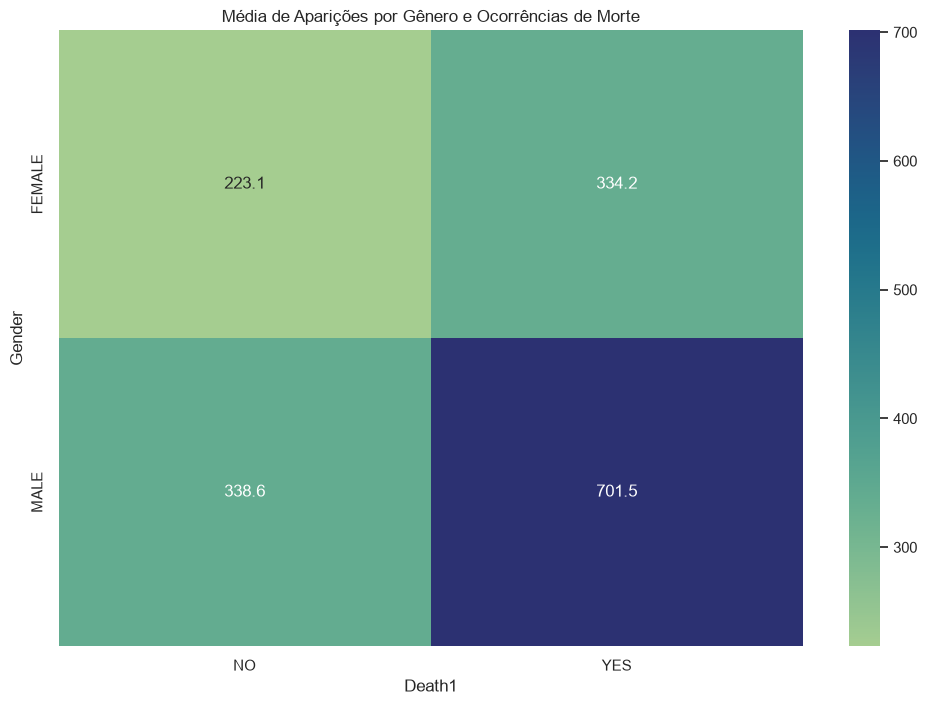

In [139]:
plt.figure(figsize=(12,8))

df_heatmap = df.pivot_table(
    index='Gender',
    columns='Death1',
    values='Appearances',
    aggfunc='mean'
)

sns.heatmap(df_heatmap, annot=True, fmt='.1f', cmap='crest', xticklabels=['NO', 'YES'])

plt.title('Média de Aparições por Gênero e Ocorrências de Morte')
plt.show()

Os resultados sugerem uma associação positiva entre o número de aparições e a ocorrência de morte, especialmente entre o gênero MALE. Além disso, o gênero MALE apresenta médias de aparições substancialmente superiores às do gênero FEMALE, sendo o grupo "MALE + DEATH1='YES'" o que concentra o maior nível de exposição.